# Phishing Emails EDA, Logistic Regression, and KNN

This notebook performs exploratory data analysis and builds two supervised text classifiers:

- Logistic Regression with TF-IDF features
- K-Nearest Neighbors with TF-IDF features

Dataset path: `/home/durgaumadev/Documents/MTech/Security for Data Science/phishing/Phishing_Emails.csv`

## 1. Imports and Settings

In [1]:
import os
from collections import Counter
from pathlib import Path
import re
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 160)

## 1.1 Helper Functions

In [2]:
def basic_text_eda(data, label_col="label", text_col="text"):
    """Create reusable text statistics for EDA."""
    eda_df = data.copy()
    eda_df[text_col] = eda_df[text_col].fillna("").astype(str)
    eda_df["char_count"] = eda_df[text_col].str.len()
    eda_df["word_count"] = eda_df[text_col].str.split().str.len()
    eda_df["unique_word_count"] = eda_df[text_col].str.lower().str.findall(r"[a-zA-Z]{2,}").map(lambda words: len(set(words)))
    eda_df["avg_word_length"] = eda_df[text_col].str.findall(r"[a-zA-Z]+").map(
        lambda words: np.mean([len(word) for word in words]) if words else 0
    )
    return eda_df


def show_label_distribution(data, label_col="label"):
    label_counts = data[label_col].value_counts().rename_axis(label_col).reset_index(name="count")
    label_counts["percentage"] = (label_counts["count"] / len(data) * 100).round(2)
    display(label_counts)

    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=data, x=label_col, order=label_counts[label_col])
    ax.set_title("Class Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Number of records")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_text_lengths(eda_df, label_col="label"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    clipped_chars = eda_df["char_count"].clip(upper=eda_df["char_count"].quantile(0.95))
    sns.histplot(
        data=eda_df.assign(char_count_clipped=clipped_chars),
        x="char_count_clipped",
        hue=label_col,
        bins=40,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[0],
    )
    axes[0].set_title("Character Count Distribution (95th percentile clipped)")
    axes[0].set_xlabel("Characters")

    clipped_words = eda_df["word_count"].clip(upper=eda_df["word_count"].quantile(0.95))
    sns.boxplot(data=eda_df.assign(word_count_clipped=clipped_words), x=label_col, y="word_count_clipped", ax=axes[1])
    axes[1].set_title("Word Count by Class (95th percentile clipped)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Words")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


def top_words_by_label(data, label_value, text_col="text", label_col="label", n=20):
    text = " ".join(data.loc[data[label_col] == label_value, text_col].dropna().astype(str).str.lower())
    words = re.findall(r"[a-zA-Z]{3,}", text)
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return pd.DataFrame(Counter(words).most_common(n), columns=["word", "count"])


def evaluate_model(name, model, X_train, X_test, y_train, y_test, positive_label):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1,
    }

    print(f"{name} classification report")
    report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
    display(report)

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d", xticks_rotation=30)
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    if len(labels) == 2 and hasattr(model, "predict_proba"):
        try:
            positive_index = list(model.classes_).index(positive_label)
            y_score = model.predict_proba(X_test)[:, positive_index]
            y_test_binary = (y_test == positive_label).astype(int)
            metrics["roc_auc"] = roc_auc_score(y_test_binary, y_score)
            RocCurveDisplay.from_predictions(y_test_binary, y_score, name=name)
            plt.title(f"{name} ROC Curve")
            plt.tight_layout()
            plt.show()
        except ValueError:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, model

## 2. Load Dataset

In [3]:
DATA_PATH = Path(r"/home/durgaumadev/Documents/MTech/Security for Data Science/phishing/Phishing_Emails.csv")
df_raw = pd.read_csv(DATA_PATH)

df = (
    df_raw[["Email Text", "Email Type"]]
    .rename(columns={"Email Text": "text", "Email Type": "label"})
    .copy()
)

df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].astype(str)

## 3. Basic Structure

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

print("\nData types and missing values")
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}))

Shape: (18650, 2)

Columns: ['text', 'label']


,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are ve...",Safe Email
1,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus v...,Safe Email
2,re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anit...,Safe Email
3,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n F...",Phishing Email
4,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent ....",Phishing Email



Data types and missing values


,dtype,missing,missing_pct
text,str,0,0.0
label,str,0,0.0


## 4. Class Balance

,label,count,percentage
0,Safe Email,11322,60.71
1,Phishing Email,7328,39.29


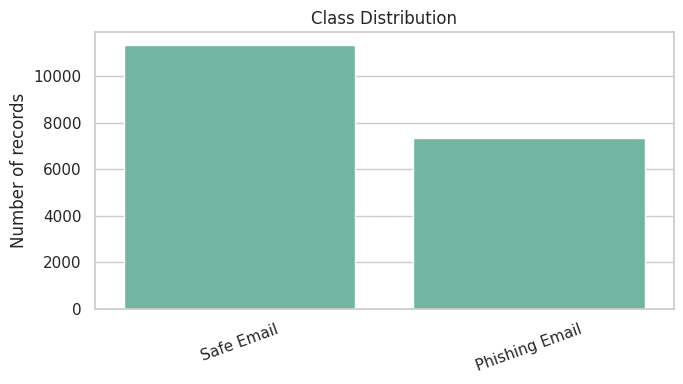

In [5]:
show_label_distribution(df, label_col="label")

## 5. Missing Values, Blank Text, and Duplicates

In [6]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text",
        "blank_text",
        "missing_label",
        "duplicate_rows",
        "duplicate_texts",
    ],
    "value": [
        len(df),
        df["text"].isna().sum(),
        df["text"].fillna("").str.strip().eq("").sum(),
        df["label"].isna().sum(),
        df.duplicated().sum(),
        df["text"].duplicated().sum(),
    ],
})
display(quality_summary)

display(df[df["text"].duplicated(keep=False)].sort_values("text").head(10))

,metric,value
0,rows,18650
1,missing_text,0
2,blank_text,19
3,missing_label,0
4,duplicate_rows,1111
5,duplicate_texts,1112


,text,label
6821,,Phishing Email
3627,,Phishing Email
31,,Phishing Email
2049,,Phishing Email
3806,,Phishing Email
9999,,Phishing Email
6299,,Phishing Email
1883,,Phishing Email
11320,,Phishing Email
8594,,Phishing Email


## 6. Text Length Analysis

char_count                                                  \
                    count     mean        std  min    25%    50%      75%   
label                                                                       
Phishing Email     7328.0  1610.40    3349.38  0.0  353.0  731.0  1566.25   
Safe Email        11322.0  3493.01  160168.02  5.0  444.0  994.5  2029.75   

                           word_count          ... unique_word_count           \
                       max      count    mean  ...               75%      max   
label                                          ...                              
Phishing Email    129635.0     7328.0  301.19  ...             136.0  11472.0   
Safe Email      17036692.0    11322.0  685.87  ...             161.0  51944.0   

               avg_word_length                                            
                         count  mean   std   min   25%   50%   75%   max  
label                                                                     
Phishing Email          7328.0  4.84  0.87  0.00  4.42  4.77  5.10  26.0  
Safe Email             11322.0  4.75  0.56  2.18  4.35  4.66  5.05   9.0  

[2 rows x 32 columns]

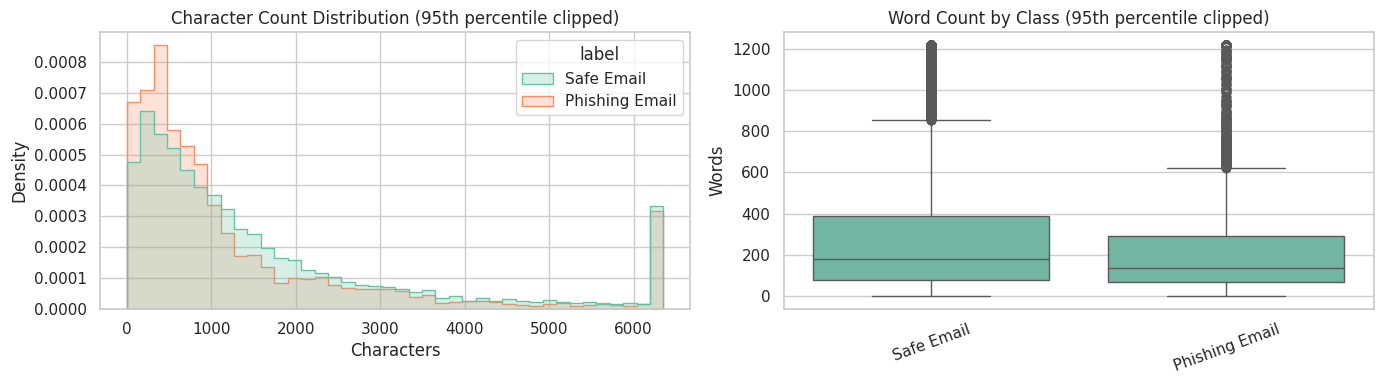

In [7]:
eda_df = basic_text_eda(df)

display(
    eda_df.groupby("label")[["char_count", "word_count", "unique_word_count", "avg_word_length"]]
    .describe()
    .round(2)
)

plot_text_lengths(eda_df)

## 7. Most Frequent Words by Class

In [8]:
for label_value in sorted(df["label"].dropna().unique()):
    print(f"Top words for: {label_value}")
    display(top_words_by_label(df, label_value, n=20))

Top words for: Phishing Email


,word,count
0,com,6176
1,email,5418
2,http,4941
3,free,4533
4,mail,3983
5,money,3930
6,company,3915
7,information,3898
8,business,3623
9,time,3384


Top words for: Safe Email


,word,count
0,enron,19273
1,language,17221
2,university,17194
3,http,16210
4,com,15359
5,subject,11101
6,ect,11005
7,information,10866
8,www,10570
9,new,10418


## 8. Prepare Data for Modeling

Rows after cleaning: 17536


,label,count,percentage
0,Safe Email,10979,62.61
1,Phishing Email,6557,37.39


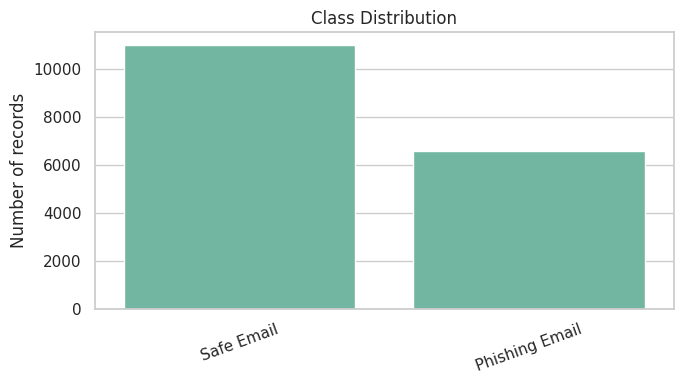

Train size: 14028
Test size: 3508


In [9]:
POSITIVE_LABEL = 'Phishing Email'

model_df = df.dropna(subset=["label"]).copy()
model_df["text"] = model_df["text"].fillna("").astype(str)
model_df = model_df[model_df["text"].str.strip().ne("")]
model_df = model_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Rows after cleaning:", len(model_df))
show_label_distribution(model_df, label_col="label")

X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

## 9. Logistic Regression

Logistic Regression classification report


,precision,recall,f1-score,support
Phishing Email,0.956973,0.983232,0.969925,1312.000000
Safe Email,0.989815,0.973588,0.981635,2196.000000
accuracy,0.977195,0.977195,0.977195,0.977195
macro avg,0.973394,0.978410,0.975780,3508.000000
weighted avg,0.977532,0.977195,0.977255,3508.000000


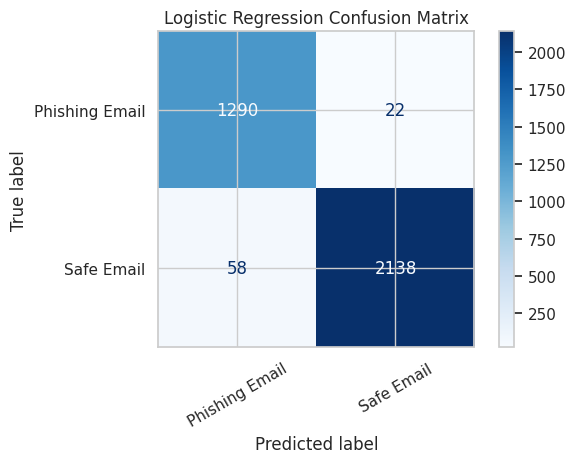

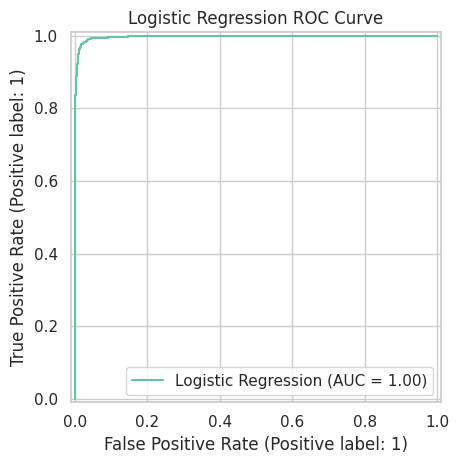

In [10]:
logistic_regression = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=12000,
            ),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

results = []
trained_models = {}

metrics, trained_model = evaluate_model(
    "Logistic Regression",
    logistic_regression,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["Logistic Regression"] = trained_model

## 10. K-Nearest Neighbors

KNN classification report


,precision,recall,f1-score,support
Phishing Email,0.945469,0.938262,0.941852,1312.00000
Safe Email,0.963282,0.967668,0.965470,2196.00000
accuracy,0.956670,0.956670,0.956670,0.95667
macro avg,0.954375,0.952965,0.953661,3508.00000
weighted avg,0.956620,0.956670,0.956637,3508.00000


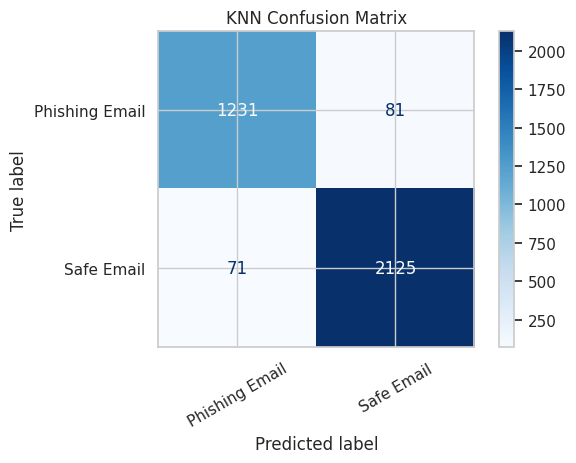

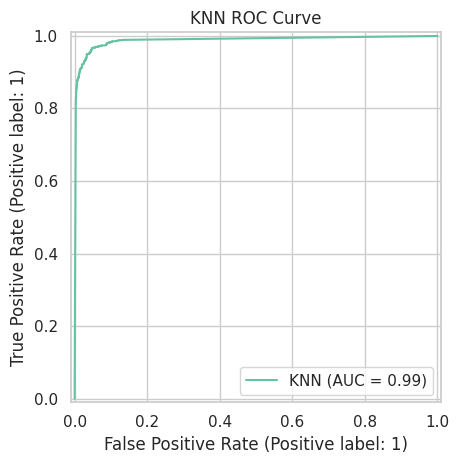

In [11]:
knn = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=7000,
            ),
        ),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5,
                weights="distance",
                metric="cosine",
                algorithm="brute",
                n_jobs=-1,
            ),
        ),
    ]
)

metrics, trained_model = evaluate_model(
    "KNN",
    knn,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["KNN"] = trained_model

## 11. Model Comparison

In [12]:
results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
display(results_df.round(4))

best_model_name = results_df.loc[0, "model"]
print(f"Best model by weighted F1: {best_model_name}")

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,roc_auc
0,Logistic Regression,0.9772,0.9775,0.9772,0.9773,0.997
1,KNN,0.9567,0.9566,0.9567,0.9566,0.988


Best model by weighted F1: Logistic Regression


## 12. Quick Error Check

In [13]:
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)

errors = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred,
})
errors = errors[errors["actual"] != errors["predicted"]]

print("Number of misclassified examples:", len(errors))
display(errors.head(15))

Number of misclassified examples: 80


,text,actual,predicted
10812,"CNET | DOWNLOAD DISPATCH(Mac Edition)\nJuly 9, 2002\nVol. 7, No. 27Using a Mac and today's music software, musicians are finding\nthat they can create, reco...",Safe Email,Phishing Email
3452,"Hallo Xxxxxxxxx Yyyyyyy,HEUTE, 03. Juli, ist monatlicher Messetag der virtuellen 3D-Job-Messe!!\nIhre Chance, die Weichen fuer einen erfolgreichen Berufsein...",Safe Email,Phishing Email
4460,"May 7, 2002\nDear rod-3ds@arsecandle.org:\nCongratulations! On behalf of Frito-Lay, Inc., we are pleased to advise you\n that you've won Fourth Prize in th...",Safe Email,Phishing Email
3132,\nDownload Dispatch - PC Edition\nDownloads\n All\nCNET\n The\nWeb\n \nIn Utilities:\nCloneCD 4.0\nIn Audio:\nSound Forge 6.0a build 150\nMedia Jukebox 8....,Safe Email,Phishing Email
9331,"\nA groys gesheft zol er hobn mit shroyre vus er hot, zol men bay im nit\nfregn, un vos men fregt zol er nisht hobn, and if that aint the truth\nnutin is.\n",Safe Email,Phishing Email
6917,nymex invitation - learn power trading power trading fundamentals : sept 15 - 16 nymex in nyc early bird discount now in effect ! nymex power delegates will...,Phishing Email,Safe Email
8769,"franz boas dear fellow linguists . i am a graduate student in taichung , taiwan . recently , i am interested in boas ' life , personality , and work . it is...",Safe Email,Phishing Email
10039,"london visit hi maureen how many days are you coming over for ? in addition to the couple of days you ' ll be spending at brook hunt , i can see one further...",Safe Email,Phishing Email
17206,geir ' s goals ),Safe Email,Phishing Email
4616,\nInteresting ebay item......(and no it wasnt me even though the spellingis\noddly familar)http://cgi.ebay.com/aw-cgi/eBayISAPI.dll?MfcISAPICommand=ViewItem...,Safe Email,Phishing Email


## Conclusion

Use the comparison table above to report which model performed better on this train/test split. In most text-classification problems, Logistic Regression with TF-IDF is a strong baseline because it handles sparse high-dimensional text features well. KNN is included for comparison, but it can be slower and more sensitive to feature dimensionality.